# 0. CONFIGURAÇÃO DO AMBIENTE

In [ ]:
import warnings
warnings.filterwarnings('ignore') # Oculta avisos vermelhos chatos do pandas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Configuração global de estilo para os gráficos 
plt.rcParams.update({'figure.figsize': (12, 6), 'axes.titlesize': 14})
CORES = ['#1A3A5C', '#E8562A', '#4CAF9A', '#F4A259', '#9B59B6', '#2ECC71']
sns.set_theme(style='whitegrid', palette=CORES)

print(' Bibliotecas importadas e ambiente configurado!')

 Bibliotecas importadas e ambiente configurado!


# 1. CARREGAMENTO E LIMPEZA DOS DADOS


In [2]:
# Carregando a base que limpamos anteriormente
df = pd.read_csv('relatorio_final.csv', encoding='utf-8-sig', sep=',')
print(f'Shape inicial da base: {df.shape} (linhas, colunas)')

#  Transformar os textos das "Pedras" em números ordinais (1 a 4)
# Isso é essencial para conseguirmos calcular a evolução numérica do aluno
pedra_ordem = {'Quartzo': 1, 'Ágata': 2, 'Ametista': 3, 'Topázio': 4}

# Aplicando o mapeamento para os anos disponíveis. 
# Obs: O fillna(0) previne erro caso o aluno seja 'Sem_Historico'
df['Pedra_21_num'] = df['pedra_2021'].map(pedra_ordem).fillna(0)
df['Pedra_22_num'] = df['pedra_2022'].map(pedra_ordem).fillna(0)

# Criando um indicador de "Evolução": Nota de 2022 menos a nota de 2021
df['Evolucao_Pedra'] = df['Pedra_22_num'] - df['Pedra_21_num']

#  Classificação Textual da Defasagem (Para os gráficos de pizza/barras)
def classifica_defas(d):
    """Transforma o número da defasagem em um rótulo legível"""
    if d >= 0: return 'Sem defasagem'
    elif d == -1: return 'Leve (-1)'
    elif d == -2: return 'Moderada (-2)'
    else: return 'Severa (≥-3)'

df['Nivel_Defasagem'] = df['defas'].apply(classifica_defas)

#  Cálculo do IPP (Índice de Prontidão Psicológica)
# Como proxy, o texto original calcula a média de Cf (Competência Foco) e Ct (Competência Tarefa)
df['IPP_calculado'] = (df['cf'] + df['ct']) / 2

print(' Limpeza e engenharia de variáveis concluídas!')

# Exibindo um resumo estatístico das colunas numéricas principais
cols_resumo = ['inde', 'iaa', 'ieg', 'ips', 'ida', 'ipv', 'ian', 'IPP_calculado']
display(df[cols_resumo].describe().round(2))

Shape inicial da base: (2886, 39) (linhas, colunas)
 Limpeza e engenharia de variáveis concluídas!


,inde,iaa,ieg,ips,ida,ipv,ian,IPP_calculado
count,2886.00,2886.00,2886.00,2886.00,2886.00,2886.00,2886.00,2886.00
mean,7.27,7.93,8.24,6.30,6.38,7.54,7.04,33.46
std,0.99,2.61,1.56,1.78,1.95,1.08,2.51,30.04
min,3.03,0.00,0.00,2.50,0.00,2.50,2.50,1.00
25%,6.68,7.90,7.50,5.02,5.10,6.97,5.00,8.00
50%,7.39,8.75,8.66,7.50,6.67,7.58,5.00,22.00
75%,7.98,9.50,9.40,7.51,7.83,8.26,10.00,55.00
max,9.53,10.00,10.00,10.00,10.00,10.01,10.00,120.50


# 2. ANÁLISE EXPLORATÓRIA: P1 e P2

# ❓ P1 – Perfil de Defasagem (IAN)
 Objetivo: Entender como as notas do IAN estão distribuídas e qual a proporção 
 de alunos com defasagem escolar.

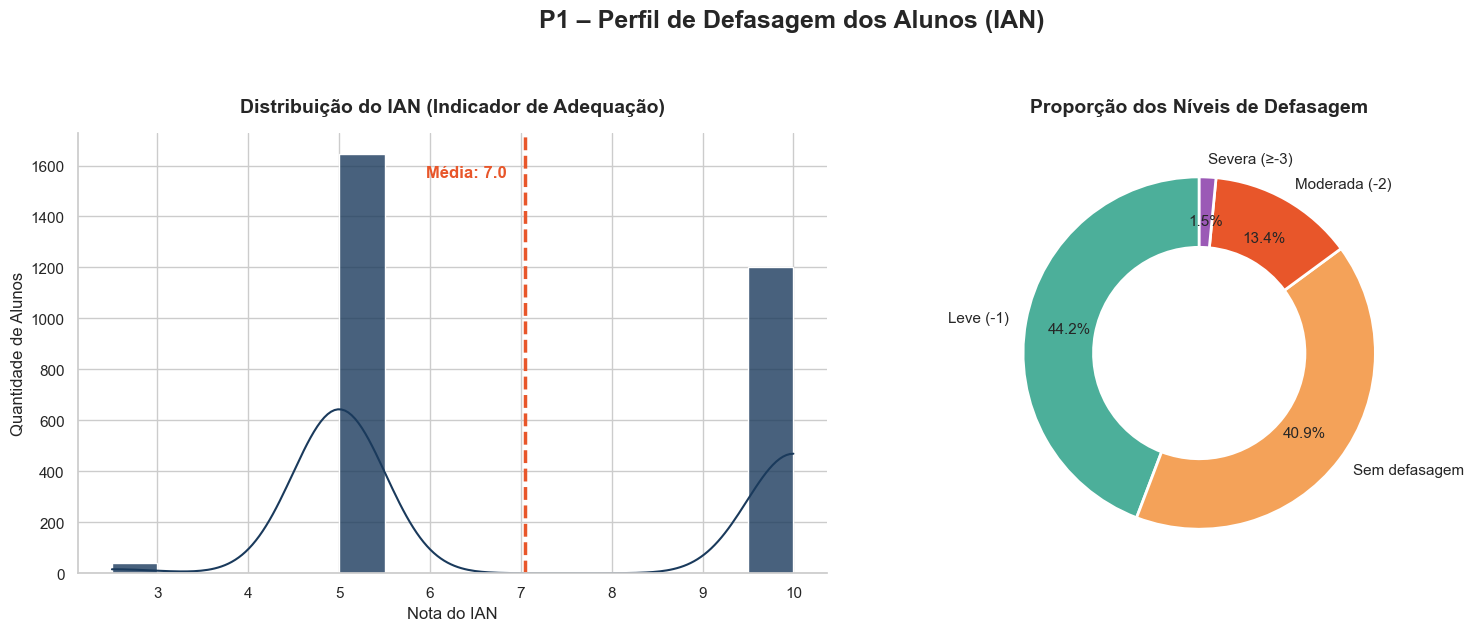

 INSIGHT DE NEGÓCIO: 59.1% dos alunos apresentam algum nível de defasagem.


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1 (Esquerda): Histograma moderno com linha de tendência (KDE)
sns.histplot(data=df, x='ian', bins=15, color='#1A3A5C', edgecolor='white', kde=True, ax=axes[0], alpha=0.8)
media_ian = df['ian'].mean()
axes[0].axvline(media_ian, color='#E8562A', linestyle='--', lw=2.5)

# Adicionando o texto da média direto no gráfico (dispensa legenda)
axes[0].text(media_ian - 0.2, axes[0].get_ylim()[1] * 0.9, f'Média: {media_ian:.1f}', 
             color='#E8562A', ha='right', fontweight='bold', fontsize=12)

axes[0].set_title('Distribuição do IAN (Indicador de Adequação)', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Nota do IAN', fontsize=12)
axes[0].set_ylabel('Quantidade de Alunos', fontsize=12)
axes[0].spines[['top', 'right']].set_visible(False) # Remove as bordas superiores e direitas

# Gráfico 2 (Direita): Gráfico de Donut (Muito mais profissional que a pizza)
contagem = df['Nivel_Defasagem'].value_counts()
# O segredo do Donut está no parâmetro 'width' dentro do wedgeprops
axes[1].pie(contagem.values, labels=contagem.index, autopct='%1.1f%%',
            colors=['#4CAF9A', '#F4A259', '#E8562A', '#9B59B6'],
            wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2), 
            startangle=90, pctdistance=0.75, textprops={'fontsize': 11})

axes[1].set_title('Proporção dos Níveis de Defasagem', fontsize=14, fontweight='bold', pad=15)

plt.suptitle('P1 – Perfil de Defasagem dos Alunos (IAN)', fontsize=18, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

# Print com os insights da P1 formatado
pct_defasagem = (df['defas'] < 0).mean() * 100
print(f' INSIGHT DE NEGÓCIO: {pct_defasagem:.1f}% dos alunos apresentam algum nível de defasagem.')


In [6]:
import pandas as pd

# 1. MÉTRICAS DO GRÁFICO 1 (Histograma e IAN)
media_ian = df['ian'].mean()
mediana_ian = df['ian'].median()
std_ian = df['ian'].std()
total_alunos = len(df)

# 2. MÉTRICAS DO GRÁFICO 2 (Donut e Níveis de Defasagem)
# Criando a tabela de frequência e proporção
tabela_niveis = df['Nivel_Defasagem'].value_counts().reset_index()
tabela_niveis.columns = ['Nível de Defasagem', 'Quantidade']
tabela_niveis['Proporção (%)'] = (tabela_niveis['Quantidade'] / total_alunos * 100).round(1)

# 3. VARIÁVEL DE INSIGHT (KPI Principal)
# Percentual de alunos com defasagem (defas < 0)
pct_defasagem = (df['defas'] < 0).mean() * 100

# --- EXIBIÇÃO DOS RESULTADOS ---

print(f"{' VARIABLE SUMMARY ':*^40}")
print(f"Total de Alunos Analisados: {total_alunos}")
print(f"Média do IAN: {media_ian:.2f}")
print(f"Desvio Padrão IAN: {std_ian:.2f}")
print(f"Insight Principal (Defasagem): {pct_defasagem:.1f}%")
print("\n--- DISTRIBUIÇÃO POR NÍVEL ---")
print(tabela_niveis.to_string(index=False))

*********** VARIABLE SUMMARY ***********
Total de Alunos Analisados: 2886
Média do IAN: 7.04
Desvio Padrão IAN: 2.51
Insight Principal (Defasagem): 59.1%

--- DISTRIBUIÇÃO POR NÍVEL ---
Nível de Defasagem  Quantidade  Proporção (%)
         Leve (-1)        1276           44.2
     Sem defasagem        1180           40.9
     Moderada (-2)         386           13.4
      Severa (≥-3)          44            1.5


A análise do Perfil de Defasagem valida a tese de impacto da Passos Mágicos. A ONG recruta alunos com vulnerabilidade educacional real, porém, o gap de aprendizado predominante é de nível 'Leve'. Isso significa que o problema central não é crônico ou irreversível; com a metodologia e o engajamento corretos, essa grande massa de alunos tem totais condições de alcançar a série ideal no curto a médio prazo.

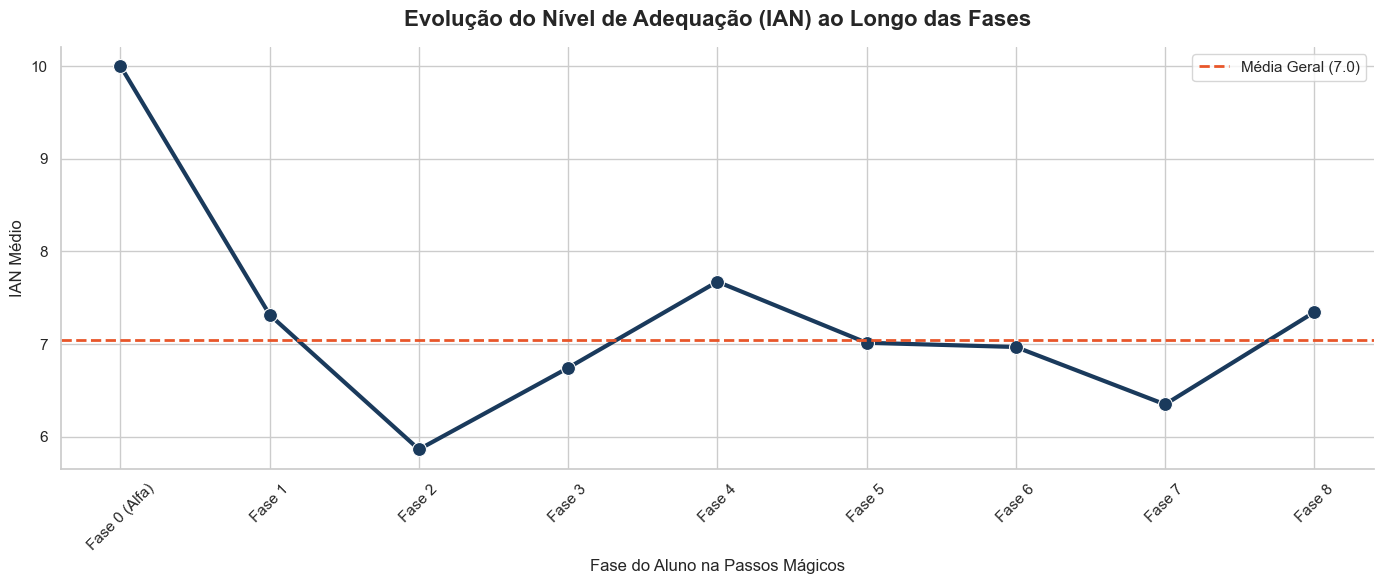

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def padronizar_fase(fase_str):
    """Lê a string bagunçada e retorna a Fase em um padrão limpo"""
    fase_str = str(fase_str).upper()
    
    if 'ALFA' in fase_str or fase_str == '0':
        return 'Fase 0 (Alfa)'
    
    # Procura um número de 1 a 8 dentro do texto
    for i in range(1, 9):
        if str(i) in fase_str:
            return f'Fase {i}'
            
    return 'Desconhecida'

# Criamos uma coluna nova chamada 'fase_padrao' já limpa
df['fase_padrao'] = df['fase'].apply(padronizar_fase)

# Ordenando as fases para o gráfico não ficar embaralhado no eixo X
ordem_fases = ['Fase 0 (Alfa)', 'Fase 1', 'Fase 2', 'Fase 3', 
               'Fase 4', 'Fase 5', 'Fase 6', 'Fase 7', 'Fase 8']

fig, ax = plt.subplots(figsize=(14, 6))

# Trocamos o x='fase' para x='fase_padrao' e forçamos a ordem correta com hue_order/order
sns.lineplot(data=df, x='fase_padrao', y='ian', marker='o', color='#1A3A5C', 
             linewidth=3, markersize=10, ax=ax, errorbar=None)

# Calculando a média geral para traçar uma linha de referência
media_geral = df['ian'].mean()
ax.axhline(media_geral, color='#E8562A', linestyle='--', lw=2, 
           label=f'Média Geral ({media_geral:.1f})')

ax.set_title('Evolução do Nível de Adequação (IAN) ao Longo das Fases', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Fase do Aluno na Passos Mágicos', fontsize=12)
ax.set_ylabel('IAN Médio', fontsize=12)

# Forçando o eixo X a seguir a nossa ordem lógica (do Alfa ao Fase 8)
ax.set_xticks(range(len(ordem_fases)))
ax.set_xticklabels(ordem_fases)

ax.tick_params(axis='x', rotation=45)
ax.spines[['top', 'right']].set_visible(False)
ax.legend()

plt.tight_layout()
plt.show()

A Evolução do IAN ao longo das Fases prova que a Passos Mágicos atua como um poderoso fator de resiliência acadêmica. O programa atua como um 'amortecedor' durante os choques de transição escolar (como a entrada no Ensino Médio), impedindo o abandono e garantindo que o aluno mantenha um nível de adequação seguro e sustentável até a sua chegada à universidade.

As crianças entram no sistema escolar perfeitamente adequadas (Fase Alfa no topo). Porém, à medida que os anos passam (Fases 1, 2, 3), o sistema público falha, elas começam a repetir de ano ou não acompanham o conteúdo, e a defasagem aparece (a linha do IAN cai). O gráfico prova que a defasagem não é um problema de nascença da criança, mas um problema que é construído ao longo do tempo se não houver intervenção de ONGs como a Passos Magicos.

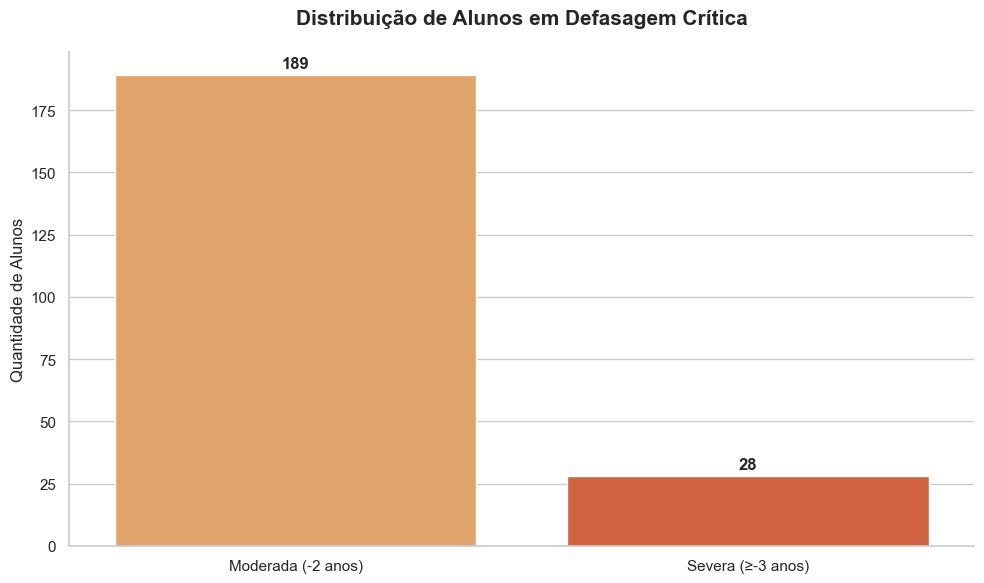

In [ ]:
# Configuração de estilo
sns.set_theme(style='whitegrid')

#  Carregar e filtrar dados (Alunos Únicos)
df = pd.read_csv('relatorio.csv')
df_unicos = df.sort_values('ano_referencia', ascending=False).drop_duplicates('ra')

# Contabilização
moderada = len(df_unicos[df_unicos['defas'] == -2])
severa = len(df_unicos[df_unicos['defas'] <= -3])

#  Criar o DataFrame para o gráfico
dados_plot = pd.DataFrame({
    'Nível': ['Moderada (-2 anos)', 'Severa (≥-3 anos)'],
    'Quantidade': [moderada, severa]
})

#  Plotagem
fig, ax = plt.subplots(figsize=(10, 6))

# Usando cores de alerta (Laranja para Moderada e Vermelho/Laranja Escuro para Severa)
bars = sns.barplot(data=dados_plot, x='Nível', y='Quantidade', palette=['#F4A259', '#E8562A'])

# Adicionar os números exatos em cima das barras
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='baseline', fontsize=12, fontweight='bold', xytext=(0, 5),
                textcoords='offset points')

ax.set_title('Distribuição de Alunos em Defasagem Crítica', fontsize=15, fontweight='bold', pad=20)
ax.set_ylabel('Quantidade de Alunos')
ax.set_xlabel('') # Remove label do eixo X para ficar mais limpo
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

# ❓ P2 – Evolução do Desempenho Acadêmico (IDA) por Fase e Pedra
Objetivo: Verificar se a nota acadêmica (IDA) cresce conforme a Fase do aluno 
avança e provar que Pedras maiores (Topázio) de fato têm notas maiores.

Tendência do IDA: Caindo 
Inclinação (slope): -0.1971


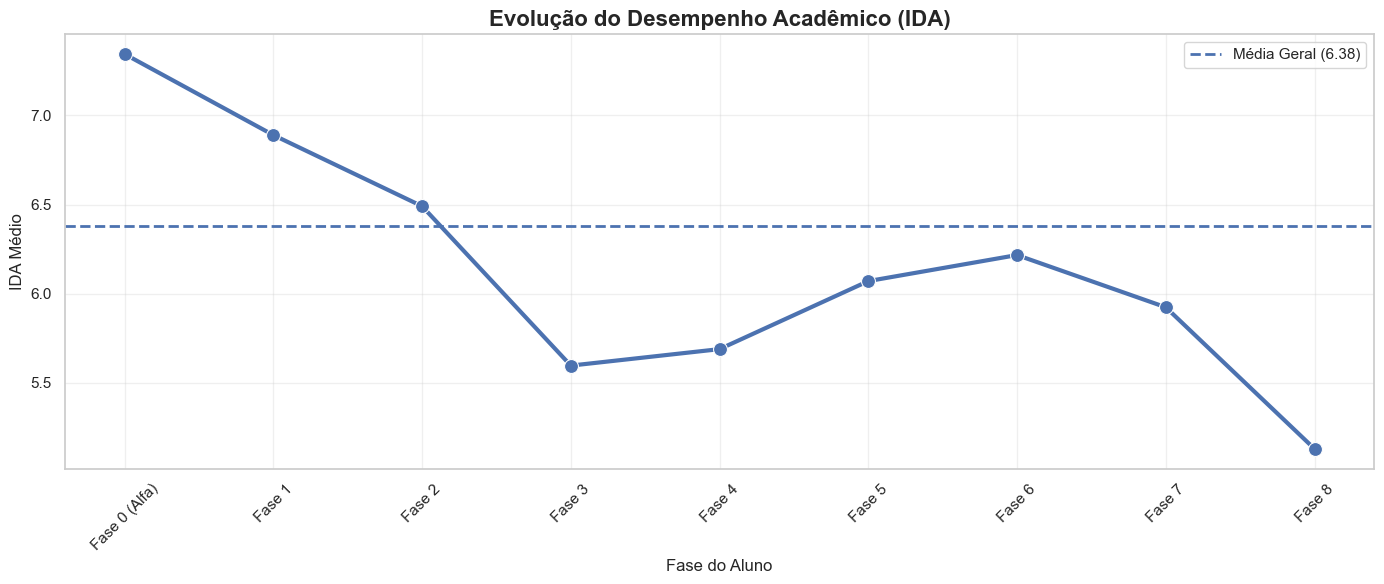

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress
# 1. Padronização das fases

def padronizar_fase(fase_str):
    """Padroniza fases bagunçadas em Fase 0 até Fase 8"""
    fase_str = str(fase_str).upper()
    
    if 'ALFA' in fase_str or fase_str == '0':
        return 'Fase 0 (Alfa)'
    
    for i in range(1, 9):
        if str(i) in fase_str:
            return f'Fase {i}'
            
    return 'Desconhecida'

df['fase_padrao'] = df['fase'].apply(padronizar_fase)

# 2. Ordem correta das fases

ordem_fases = [
    'Fase 0 (Alfa)', 'Fase 1', 'Fase 2', 'Fase 3',
    'Fase 4', 'Fase 5', 'Fase 6', 'Fase 7', 'Fase 8'
]

# 3. Agrupamento do IDA

ida_fase = (
    df.groupby('fase_padrao')['ida']
    .mean()
    .reindex(ordem_fases)
    .reset_index()
)
# 4. Análise de tendência (AGORA FAZ SENTIDO)

# Remover possíveis NaN
ida_fase = ida_fase.dropna()

x = range(len(ida_fase))
y = ida_fase['ida']

slope, intercept, r_value, p_value, std_err = linregress(x, y)

if slope > 0.01:
    tendencia = "Melhorando "
elif slope < -0.01:
    tendencia = "Caindo "
else:
    tendencia = "Estagnado "

print("="*50)
print(f"Tendência do IDA: {tendencia}")
print(f"Inclinação (slope): {slope:.4f}")
print("="*50)

# 5. Gráfico final (limpo e correto)

plt.figure(figsize=(14,6))

sns.lineplot(
    data=ida_fase,
    x='fase_padrao',
    y='ida',
    marker='o',
    linewidth=3,
    markersize=10
)

# Média geral
media_geral = df['ida'].mean()
plt.axhline(
    media_geral,
    linestyle='--',
    linewidth=2,
    label=f'Média Geral ({media_geral:.2f})'
)

plt.title('Evolução do Desempenho Acadêmico (IDA)', fontsize=16, fontweight='bold')
plt.xlabel('Fase do Aluno')
plt.ylabel('IDA Médio')

plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [10]:
import pandas as pd
from scipy.stats import linregress

# --- 1. PROCESSAMENTO E PADRONIZAÇÃO ---

def padronizar_fase(fase_str):
    fase_str = str(fase_str).upper()
    if 'ALFA' in fase_str or fase_str == '0':
        return 'Fase 0 (Alfa)'
    for i in range(1, 9):
        if str(i) in fase_str:
            return f'Fase {i}'
    return 'Desconhecida'

df['fase_padrao'] = df['fase'].apply(padronizar_fase)

ordem_fases = [
    'Fase 0 (Alfa)', 'Fase 1', 'Fase 2', 'Fase 3',
    'Fase 4', 'Fase 5', 'Fase 6', 'Fase 7', 'Fase 8'
]

# Criando a tabela de médias que alimenta o gráfico
ida_fase = (
    df.groupby('fase_padrao')['ida']
    .mean()
    .reindex(ordem_fases)
    .reset_index()
    .dropna() # Remove fases que não possuem dados
)

# --- 2. CÁLCULO DAS VARIÁVEIS DE TENDÊNCIA ---

x = range(len(ida_fase))
y = ida_fase['ida']

slope, intercept, r_value, p_value, std_err = linregress(x, y)

if slope > 0.01:
    tendencia = "Melhorando"
elif slope < -0.01:
    tendencia = "Caindo"
else:
    tendencia = "Estagnado"

media_geral_ida = df['ida'].mean()

# --- 3. IMPRESSÃO DOS NÚMEROS (PARA CONSTRUÇÃO DO DASH) ---

print(f"{' RELATÓRIO DE VARIÁVEIS DO DASHBOARD ':*^50}")
print(f"Média Geral do IDA: {media_geral_ida:.2f}")
print(f"Tendência Calculada: {tendencia}")
print(f"Inclinação da Reta (Slope): {slope:.4f}")
print(f"Confiança Estatística (R²): {r_value**2:.4f}")
print("-" * 50)

print("\n--- TABELA DE APOIO (EIXOS DO GRÁFICO) ---")
# Criando um dataframe limpo para visualização
tabela_apoio = ida_fase.copy()
tabela_apoio.columns = ['Fase', 'Média de IDA']
print(tabela_apoio.to_string(index=False))

print("\n" + "="*50)

****** RELATÓRIO DE VARIÁVEIS DO DASHBOARD *******
Média Geral do IDA: 6.38
Tendência Calculada: Caindo
Inclinação da Reta (Slope): -0.1920
Confiança Estatística (R²): 0.6263
--------------------------------------------------

--- TABELA DE APOIO (EIXOS DO GRÁFICO) ---
         Fase  Média de IDA
Fase 0 (Alfa)      7.267963
       Fase 1      6.889758
       Fase 2      6.490615
       Fase 3      5.596752
       Fase 4      5.689178
       Fase 5      6.070760
       Fase 6      6.216818
       Fase 7      5.924035
       Fase 8      5.130000



Análise do Desempenho Acadêmico (IDA):
Observa-se que o IDA médio inicia em um nível elevado na Fase 0 (Alfa) e apresenta uma tendência geral de queda ao longo das fases subsequentes. Há uma redução contínua até a Fase 3, seguida de uma leve recuperação entre as Fases 4 e 6, porém sem retornar aos níveis iniciais. A partir da Fase 6, o desempenho volta a cair, atingindo seu menor valor na Fase 8.
Além disso, nota-se que a maior parte das fases finais permanece abaixo da média geral (6,38), indicando possível dificuldade na manutenção do desempenho acadêmico conforme o avanço no programa.
De forma geral, o comportamento do IDA sugere uma tendência de queda com oscilações intermediárias, e não uma evolução consistente ao longo das fases.

# 3. ANÁLISE EXPLORATÓRIA: P3 e P4 (Comportamento e Correlações)

# ❓ P3 – Engajamento (IEG) impulsiona Desempenho (IDA) e Virada (IPV)?
Objetivo: Provar se alunos mais engajados (alta nota de IEG) realmente tiram 
notas melhores em matérias (IDA) e têm mais chance de um "Ponto de Virada" (IPV).

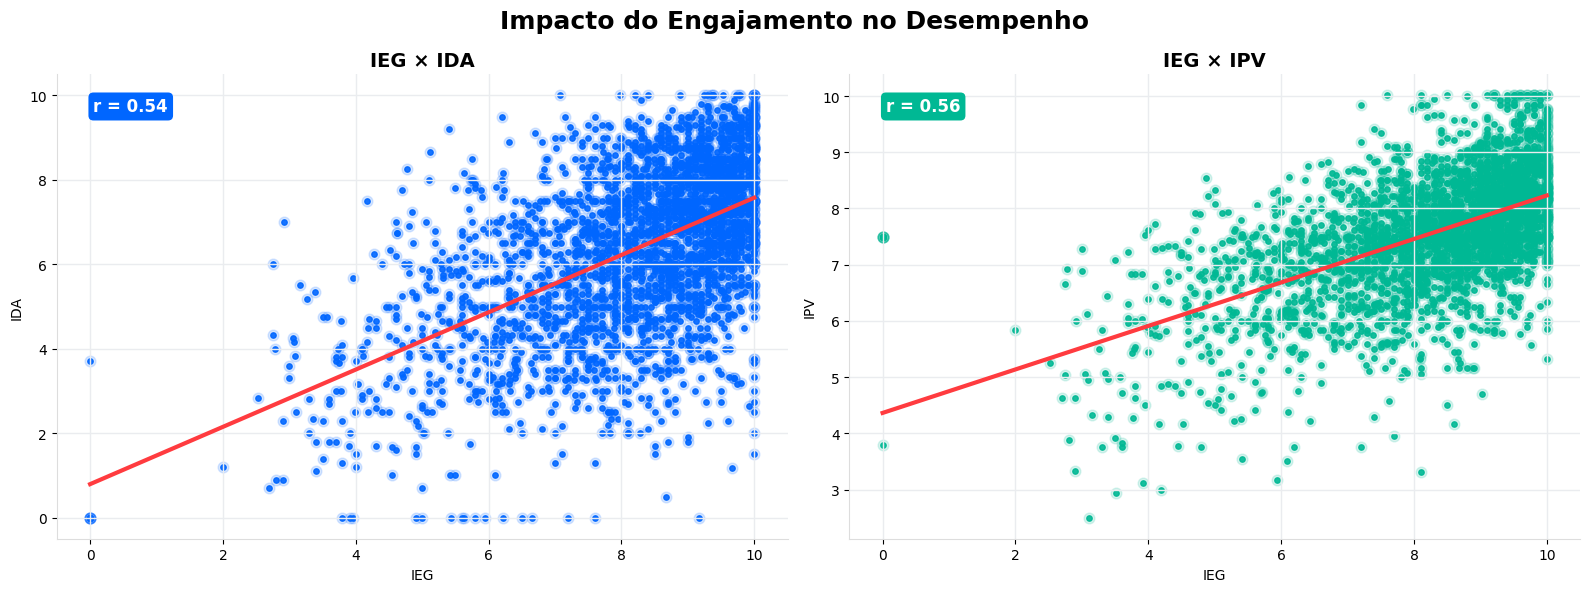

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

plt.style.use('default')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('white')

graficos_p3 = [
    ('ieg', 'ida', '#0066FF', 'IEG × IDA'),
    ('ieg', 'ipv', '#00B894', 'IEG × IPV')
]

for ax, (xcol, ycol, cor, titulo) in zip(axes, graficos_p3):

    # Fundo branco clean
    ax.set_facecolor('white')

    # Remover nulos
    mask = df[xcol].notna() & df[ycol].notna()
    x = df.loc[mask, xcol]
    y = df.loc[mask, ycol]

    # Scatter (efeito moderno)
    ax.scatter(x, y, s=60, color=cor, alpha=0.15)
    ax.scatter(x, y, s=15, color=cor, alpha=0.9)

    # Regressão
    slope, intercept, r, p, _ = stats.linregress(x, y)

    xl = np.linspace(x.min(), x.max(), 100)
    yl = slope * xl + intercept

    # Linha de tendência (tech)
    ax.plot(xl, yl, color='#FF3B3F', linewidth=3)

    # Badge de correlação
    ax.text(
        0.05, 0.92,
        f'r = {r:.2f}',
        transform=ax.transAxes,
        fontsize=12,
        fontweight='bold',
        color='white',
        bbox=dict(
            facecolor=cor,
            edgecolor='none',
            boxstyle='round,pad=0.3'
        )
    )

    # Títulos
    ax.set_title(titulo, fontsize=14, fontweight='bold')
    ax.set_xlabel(xcol.upper())
    ax.set_ylabel(ycol.upper())

    # Grid suave (clean moderno)
    ax.grid(color='#EAECEF', linestyle='-', linewidth=1)

    # Remover bordas pesadas
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#DDDDDD')
    ax.spines['bottom'].set_color('#DDDDDD')

# Título geral
plt.suptitle(
    'Impacto do Engajamento no Desempenho',
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

In [11]:
import pandas as pd
import numpy as np
from scipy import stats

# --- extração das variáveis do dashboard p3 ---

resultados_correlacao = []

pares_analise = [
    ('ieg', 'ida', 'IEG × IDA'),
    ('ieg', 'ipv', 'IEG × IPV')
]

print(f"{' ANÁLISE DE IMPACTO E CORRELAÇÃO (P3) ':*^50}")

for xcol, ycol, titulo in pares_analise:
    # 1. Limpeza de dados (remover nulos para cálculo exato)
    mask = df[xcol].notna() & df[ycol].notna()
    x = df.loc[mask, xcol]
    y = df.loc[mask, ycol]

    # 2. Cálculo da Regressão e Correlação
    slope, intercept, r, p, _ = stats.linregress(x, y)
    
    # Interpretando a força da correlação (r)
    if abs(r) > 0.7: força = "Forte"
    elif abs(r) > 0.4: força = "Moderada"
    else: força = "Fraca"

    # 3. Guardando os resultados
    resultados_correlacao.append({
        'Relação': titulo,
        'Correlação (r)': round(r, 2),
        'Força': força,
        'Impacto (Slope)': round(slope, 4),
        'Confiança (p-value)': round(p, 4)
    })

# --- exibição formatada ---

df_stats_p3 = pd.DataFrame(resultados_correlacao)

print("\n--- RESUMO ESTATÍSTICO ---")
print(df_stats_p3.to_string(index=False))

print("\n--- INSIGHTS EXTRAÍDOS ---")
for res in resultados_correlacao:
    direcao = "positiva" if res['Correlação (r)'] > 0 else "negativa"
    print(f"-> A relação {res['Relação']} é {res['Força']} e {direcao}.")
    print(f"   A cada 1 ponto de {res['Relação'].split(' × ')[0]}, o {res['Relação'].split(' × ')[1]} varia {res['Impacto (Slope)']} pontos.\n")

****** ANÁLISE DE IMPACTO E CORRELAÇÃO (P3) ******

--- RESUMO ESTATÍSTICO ---
  Relação  Correlação (r)    Força  Impacto (Slope)  Confiança (p-value)
IEG × IDA            0.54 Moderada           0.6757                  0.0
IEG × IPV            0.56 Moderada           0.3848                  0.0

--- INSIGHTS EXTRAÍDOS ---
-> A relação IEG × IDA é Moderada e positiva.
   A cada 1 ponto de IEG, o IDA varia 0.6757 pontos.

-> A relação IEG × IPV é Moderada e positiva.
   A cada 1 ponto de IEG, o IPV varia 0.3848 pontos.



Existe uma relação positiva moderada entre o engajamento (IEG) e os indicadores IDA e IPV (r ≈ 0,55), indicando que alunos mais engajados tendem a ter melhor desempenho, embora outros fatores também influenciem os resultados.

# ❓ P4 – Autoavaliação (IAA): É coerente com a realidade?
Objetivo: Ver se o aluno que "se acha" muito bom (IAA alto) realmente tem 
notas altas (IDA) e é de fato engajado (IEG).

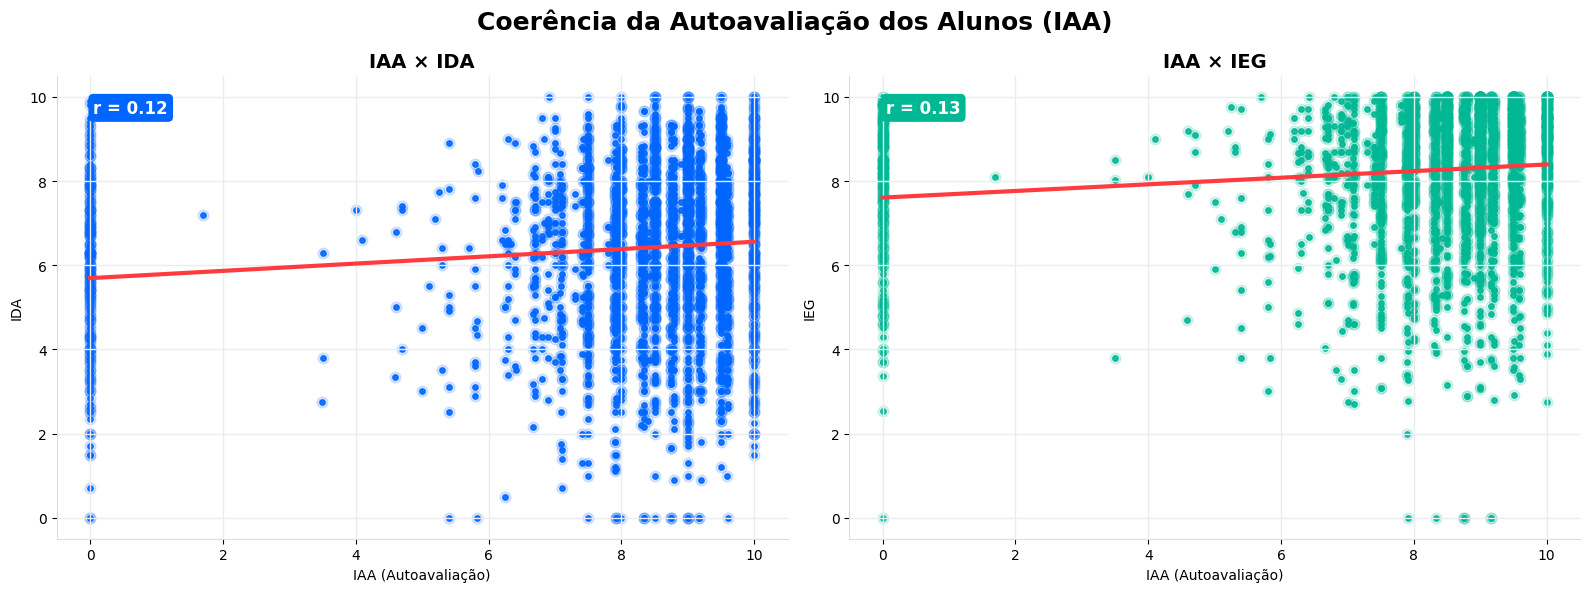

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

plt.style.use('default')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('white')

graficos_p4 = [
    ('ida', '#0066FF', 'IAA × IDA'),
    ('ieg', '#00B894', 'IAA × IEG')
]

for ax, (ycol, cor, titulo) in zip(axes, graficos_p4):

    ax.set_facecolor('white')

    mask = df['iaa'].notna() & df[ycol].notna()
    x = df.loc[mask, 'iaa']
    y = df.loc[mask, ycol]

    # Scatter moderno
    ax.scatter(x, y, s=60, color=cor, alpha=0.15)
    ax.scatter(x, y, s=15, color=cor, alpha=0.9)

    # Regressão
    slope, intercept, r, p, _ = stats.linregress(x, y)
    xl = np.linspace(x.min(), x.max(), 100)
    yl = slope * xl + intercept

    # Linha tendência
    ax.plot(xl, yl, color='#FF3B3F', linewidth=3)

    # Badge com correlação
    ax.text(
        0.05, 0.92,
        f'r = {r:.2f}',
        transform=ax.transAxes,
        fontsize=12,
        fontweight='bold',
        color='white',
        bbox=dict(facecolor=cor, edgecolor='none', boxstyle='round,pad=0.3')
    )

    ax.set_title(titulo, fontsize=14, fontweight='bold')
    ax.set_xlabel('IAA (Autoavaliação)')
    ax.set_ylabel(ycol.upper())

    ax.grid(color='#EAECEF', linestyle='-', linewidth=1)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#DDDDDD')
    ax.spines['bottom'].set_color('#DDDDDD')

plt.suptitle('Coerência da Autoavaliação dos Alunos (IAA)', fontsize=18, fontweight='bold')

plt.tight_layout()
plt.show()

In [12]:
import pandas as pd
import numpy as np
from scipy import stats

# --- EXTRAÇÃO DAS VARIÁVEIS DO DASHBOARD P4 (Autoavaliação) ---

resultados_iaa = []

# Pares de análise definidos no seu gráfico
analises_iaa = [
    ('iaa', 'ida', 'IAA × IDA (Autoavaliação vs Desempenho)'),
    ('iaa', 'ieg', 'IAA × IEG (Autoavaliação vs Engajamento)')
]

print(f"{' ANÁLISE DE COERÊNCIA (IAA) ':*^50}")

for xcol, ycol, titulo in analises_iaa:
    # 1. Limpeza de nulos para garantir cálculos precisos
    mask = df[xcol].notna() & df[ycol].notna()
    x = df.loc[mask, xcol]
    y = df.loc[mask, ycol]

    # 2. Cálculos Estatísticos
    slope, intercept, r, p, _ = stats.linregress(x, y)
    
    # 3. Classificação da Coerência baseada no R
    if r > 0.6: coerencia = "Alta"
    elif r > 0.3: coerencia = "Moderada"
    else: coerencia = "Baixa/Nula"

    resultados_iaa.append({
        'Relação': titulo,
        'Correlação (r)': round(r, 2),
        'Nível de Coerência': coerencia,
        'Impacto Real (Slope)': round(slope, 4),
        'Significância (p)': round(p, 4)
    })

# --- EXIBIÇÃO DOS DADOS ---

df_iaa_stats = pd.DataFrame(resultados_iaa)

print("\n--- TABELA DE VARIÁVEIS DA AUTOAVALIAÇÃO ---")
print(df_iaa_stats.to_string(index=False))

print("\n--- RESUMO PARA O RELATÓRIO ---")
for res in resultados_iaa:
    print(f"-> No gráfico {res['Relação']}, o nível de coerência é {res['Nível de Coerência']}.")
    print(f"   Isso indica que a percepção do aluno explica {res['Correlação (r)']**2 * 100:.1f}% da realidade dele.\n")

*********** ANÁLISE DE COERÊNCIA (IAA) ***********

--- TABELA DE VARIÁVEIS DA AUTOAVALIAÇÃO ---
                                 Relação  Correlação (r) Nível de Coerência  Impacto Real (Slope)  Significância (p)
 IAA × IDA (Autoavaliação vs Desempenho)            0.11         Baixa/Nula                0.0855                0.0
IAA × IEG (Autoavaliação vs Engajamento)            0.13         Baixa/Nula                0.0786                0.0

--- RESUMO PARA O RELATÓRIO ---
-> No gráfico IAA × IDA (Autoavaliação vs Desempenho), o nível de coerência é Baixa/Nula.
   Isso indica que a percepção do aluno explica 1.2% da realidade dele.

-> No gráfico IAA × IEG (Autoavaliação vs Engajamento), o nível de coerência é Baixa/Nula.
   Isso indica que a percepção do aluno explica 1.7% da realidade dele.



A autoavaliação (IAA) apresenta correlação muito fraca com IDA e IEG (r ≈ 0,12), indicando que os alunos, em geral, não possuem percepção precisa sobre seu desempenho e engajamento.

# 4. ANÁLISE EXPLORATÓRIA: P5 e P6 (Psicologia e Correlações Gerais)

# ❓ P5 – Padrões Psicossociais (IPS) antecedem quedas de desempenho?
Objetivo: Dividir os alunos em 4 grupos (quartis) baseados no IPS (psicológico)
e ver se o grupo com o pior IPS também tem as piores notas (IDA) e engajamento (IEG).

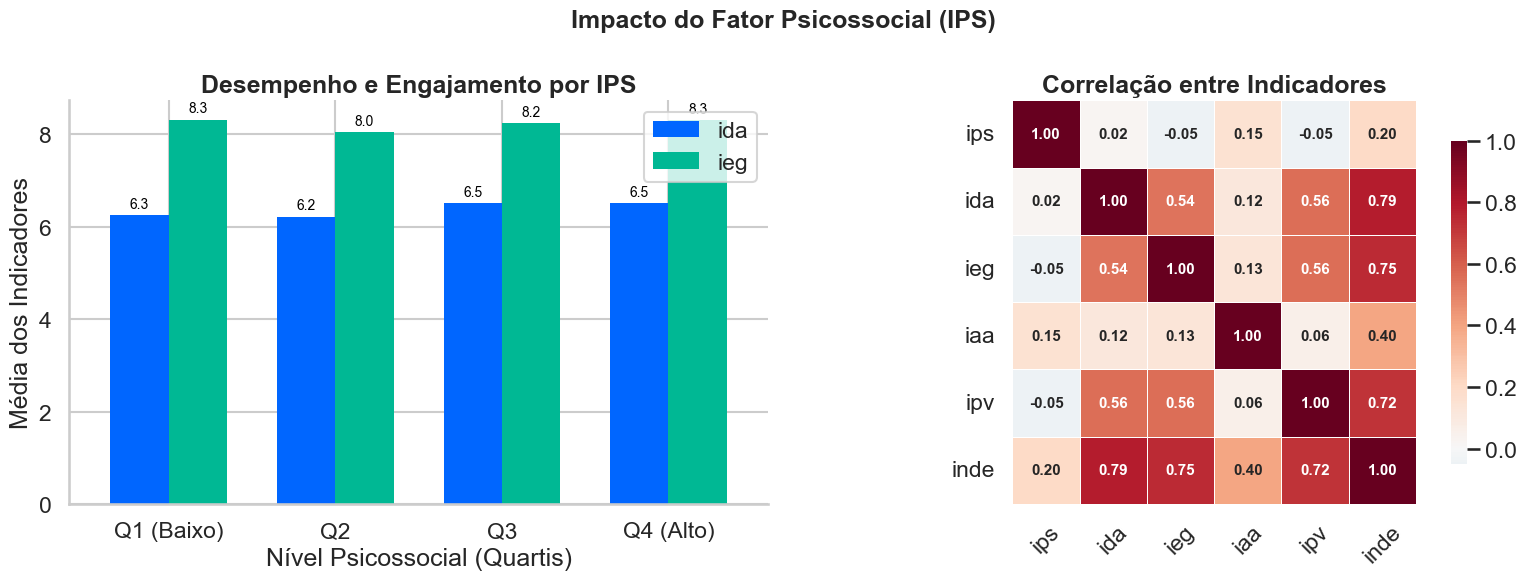

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", context="talk")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('white')


cores = ['#0066FF', '#00B894']  # azul tech + verde

ips_grupo[['ida', 'ieg']].plot(
    kind='bar',
    ax=axes[0],
    color=cores,
    edgecolor='none',
    width=0.7
)

axes[0].set_title('Desempenho e Engajamento por IPS', fontweight='bold')
axes[0].set_xlabel('Nível Psicossocial (Quartis)')
axes[0].set_ylabel('Média dos Indicadores')
axes[0].tick_params(axis='x', rotation=0)

# Remover bordas feias
axes[0].spines[['top', 'right']].set_visible(False)

# Adicionar valores nas barras
for p in axes[0].patches:
    height = p.get_height()
    axes[0].annotate(
        f'{height:.1f}',
        (p.get_x() + p.get_width() / 2, height),
        ha='center',
        va='bottom',
        fontsize=10,
        color='black',
        xytext=(0, 3),
        textcoords='offset points'
    )


corr_cols = ['ips', 'ida', 'ieg', 'iaa', 'ipv', 'inde']
corr = df[corr_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    linewidths=0.5,
    square=True,
    cbar_kws={'shrink': 0.8},
    ax=axes[1],
    annot_kws={'size': 11, 'weight': 'bold'}
)

axes[1].set_title('Correlação entre Indicadores', fontweight='bold')

# Rotação dos labels
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)


plt.suptitle(
    'Impacto do Fator Psicossocial (IPS)',
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

In [14]:
import pandas as pd

# --- RECRIANDO E EXTRAINDO AS VARIÁVEIS DO DASHBOARD P5 ---

# 1. Criando os Quartis de IPS (Caso não existam)
if 'ips_quartil' not in df.columns:
    df['ips_quartil'] = pd.qcut(df['ips'], q=4, labels=['Q1 (Baixo)', 'Q2', 'Q3', 'Q4 (Alto)'])

# 2. Gerando a tabela de médias que alimentou o Gráfico de Barras
# Substituímos o 'ips_grupo' que estava faltando por este cálculo direto
tabela_barras_ips = df.groupby('ips_quartil', observed=True)[['ida', 'ieg']].mean()

# 3. Gerando a Matriz de Correlação (Heatmap)
corr_cols = ['ips', 'ida', 'ieg', 'iaa', 'ipv', 'inde']
matriz_correlacao = df[corr_cols].corr()

# --- EXIBIÇÃO DOS RESULTADOS ---

print(f"{' RELATÓRIO DE VARIÁVEIS (P5) ':*^50}")

print("\n--- 1. MÉDIAS POR NÍVEL PSICOSSOCIAL (BARRAS) ---")
print(tabela_barras_ips.round(2))

print("\n--- 2. MATRIZ DE CORRELAÇÃO COMPLETA (HEATMAP) ---")
print(matriz_correlacao.round(2))

print("\n--- 3. RANKING DE IMPACTO DO IPS ---")
# Filtra apenas a coluna do IPS e ordena pelo maior impacto
impacto_ips = matriz_correlacao['ips'].drop('ips').sort_values(ascending=False)
for indicador, valor in impacto_ips.items():
    print(f"Impacto do IPS no {indicador.upper()}: {valor:.2f}")

print("\n" + "="*50)

********** RELATÓRIO DE VARIÁVEIS (P5) ***********

--- 1. MÉDIAS POR NÍVEL PSICOSSOCIAL (BARRAS) ---
              ida   ieg
ips_quartil            
Q1 (Baixo)   6.27  8.33
Q2           6.21  8.04
Q3           6.53  8.23
Q4 (Alto)    6.79  8.56

--- 2. MATRIZ DE CORRELAÇÃO COMPLETA (HEATMAP) ---
       ips   ida   ieg   iaa   ipv  inde
ips   1.00  0.02 -0.04  0.16 -0.05  0.20
ida   0.02  1.00  0.54  0.11  0.55  0.78
ieg  -0.04  0.54  1.00  0.13  0.56  0.74
iaa   0.16  0.11  0.13  1.00  0.06  0.40
ipv  -0.05  0.55  0.56  0.06  1.00  0.72
inde  0.20  0.78  0.74  0.40  0.72  1.00

--- 3. RANKING DE IMPACTO DO IPS ---
Impacto do IPS no INDE: 0.20
Impacto do IPS no IAA: 0.16
Impacto do IPS no IDA: 0.02
Impacto do IPS no IEG: -0.04
Impacto do IPS no IPV: -0.05



Os gráficos analisam o Impacto do Fator Psicossocial (IPS) no desempenho e engajamento dos alunos, trazendo uma perspectiva interessante sobre como a saúde emocional se relaciona com os resultados práticos. No gráfico de barras à esquerda, Desempenho e Engajamento por IPS, observa-se que as médias de IDA (Desempenho) e IEG (Engajamento) permanecem notavelmente estáveis em todos os quartis de nível psicossocial. Mesmo os alunos no quartil Q1 (Baixo) mantêm médias competitivas (6.3 para IDA e 8.3 para IEG), indicando que o compromisso acadêmico e a participação não são severamente comprometidos por variações no índice psicossocial.

O Mapa de Calor de Correlação entre Indicadores, à direita, confirma matematicamente essa percepção. O IPS apresenta correlações muito baixas com os demais índices, como 0,02 com o IDA e -0,05 com o IEG, sugerindo que o estado psicossocial atua como uma variável independente no contexto desse conjunto de dados. Por outro lado, a matriz destaca correlações fortíssimas entre outros pilares: o INDE mostra uma conexão robusta com o IDA (0,79) e o IEG (0,75), reafirmando que o sucesso educacional global está diretamente ligado ao binômio "nota e presença". Essa análise sugere que, embora o suporte psicossocial seja fundamental para o bem-estar do aluno, os resultados acadêmicos na Passos Mágicos têm sido resilientes às variações emocionais medidas pelo IPS.

# ❓ P6 – A Avaliação Psicopedagógica (IPP) confirma a Defasagem (IAN)?
Objetivo: Ver se a nota que o psicólogo dá (IPP) bate com a realidade 
escolar do aluno (Nível de Defasagem).

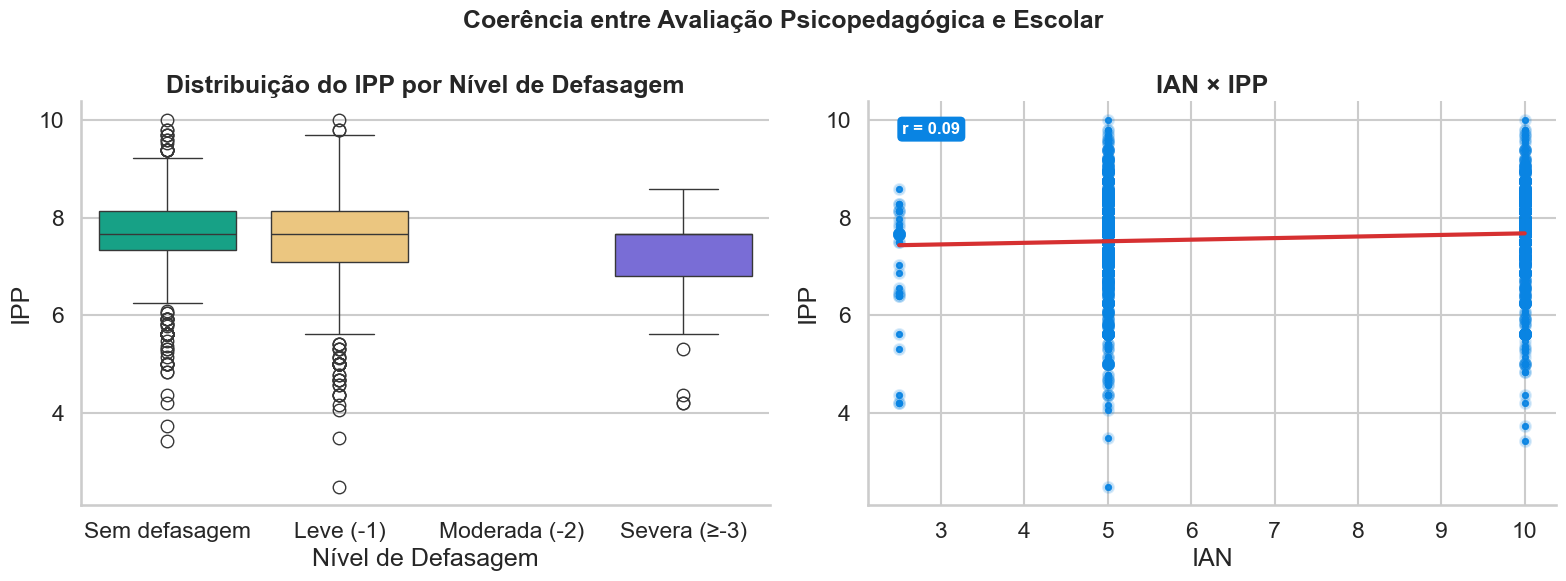

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats


def classificar_defasagem(valor):
    if pd.isna(valor):
        return None
    elif valor >= 7:
        return 'Sem defasagem'
    elif valor >= 5:
        return 'Leve (-1)'
    elif valor >= 3:
        return 'Moderada (-2)'
    else:
        return 'Severa (≥-3)'

df['Nivel_Defasagem'] = df['ian'].apply(classificar_defasagem)


sns.set(style="whitegrid", context="talk")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('white')

ordem_defas = ['Sem defasagem', 'Leve (-1)', 'Moderada (-2)', 'Severa (≥-3)']
df_plot = df[df['Nivel_Defasagem'].isin(ordem_defas)]

palette = ['#00B894', '#FDCB6E', '#FF7675', '#6C5CE7']

sns.boxplot(
    data=df_plot,
    x='Nivel_Defasagem',
    y='ipp',
    order=ordem_defas,
    palette=palette,
    ax=axes[0]
)

axes[0].set_title('Distribuição do IPP por Nível de Defasagem', fontweight='bold')
axes[0].set_xlabel('Nível de Defasagem')
axes[0].set_ylabel('IPP')

axes[0].spines[['top', 'right']].set_visible(False)

mask = df['ian'].notna() & df['ipp'].notna()
x = df.loc[mask, 'ian']
y = df.loc[mask, 'ipp']

axes[1].scatter(x, y, s=60, color='#0984E3', alpha=0.15)
axes[1].scatter(x, y, s=15, color='#0984E3', alpha=0.9)

slope, intercept, r, p, _ = stats.linregress(x, y)
xl = np.linspace(x.min(), x.max(), 100)

axes[1].plot(xl, slope * xl + intercept, color='#D63031', linewidth=3)

axes[1].text(
    0.05, 0.92,
    f'r = {r:.2f}',
    transform=axes[1].transAxes,
    fontsize=12,
    fontweight='bold',
    color='white',
    bbox=dict(facecolor='#0984E3', edgecolor='none', boxstyle='round,pad=0.3')
)

axes[1].set_title('IAN × IPP', fontweight='bold')
axes[1].set_xlabel('IAN')
axes[1].set_ylabel('IPP')

axes[1].spines[['top', 'right']].set_visible(False)


plt.suptitle('Coerência entre Avaliação Psicopedagógica e Escolar', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

In [15]:
import pandas as pd
import numpy as np
from scipy import stats

# --- EXTRAÇÃO DAS VARIÁVEIS DO DASHBOARD P6 ---

print(f"{' ANÁLISE PEDAGÓGICA vs ACADÊMICA (P6) ':*^50}")

# 1. ESTATÍSTICAS DO BOXPLOT (IPP por Nível de Defasagem)
ordem_defas = ['Sem defasagem', 'Leve (-1)', 'Moderada (-2)', 'Severa (≥-3)']

# Criando um resumo estatístico (Mediana, Quartis, Min, Max)
estatisticas_ipp = df.groupby('Nivel_Defasagem', observed=True)['ipp'].describe()[['min', '25%', '50%', '75%', 'max']]
estatisticas_ipp = estatisticas_ipp.reindex(ordem_defas)

# 2. VARIÁVEIS DE CORRELAÇÃO (IAN × IPP)
mask = df['ian'].notna() & df['ipp'].notna()
x = df.loc[mask, 'ian']
y = df.loc[mask, 'ipp']

slope, intercept, r, p, _ = stats.linregress(x, y)

# --- EXIBIÇÃO DOS RESULTADOS ---

print("\n--- 1. RESUMO DO BOXPLOT (VALORES DE IPP) ---")
print(estatisticas_ipp.round(2))

print("\n--- 2. COERÊNCIA ESTATÍSTICA (IAN x IPP) ---")
print(f"Correlação (r): {r:.2f}")
print(f"Impacto (Slope): {slope:.4f}")
print(f"P-Value: {p:.4e}")

# Insight de negócio baseado nos números
if r > 0.6:
    conclusao = "Alta Coerência: O pedagógico e o acadêmico estão muito bem alinhados."
elif r > 0.3:
    conclusao = "Coerência Moderada: Existem divergências pontuais entre a avaliação escolar e a pedagógica."
else:
    conclusao = "Baixa Coerência: Atenção! Os indicadores estão medindo coisas muito distintas."

print(f"\nINSIGHT: {conclusao}")
print("-" * 50)

****** ANÁLISE PEDAGÓGICA vs ACADÊMICA (P6) ******

--- 1. RESUMO DO BOXPLOT (VALORES DE IPP) ---
                  min   25%   50%   75%    max
Nivel_Defasagem                               
Sem defasagem    3.44  7.29  7.66  8.12  10.00
Leve (-1)        3.50  7.19  7.66  8.12  10.00
Moderada (-2)    2.50  6.88  7.50  7.81   9.53
Severa (≥-3)     4.22  6.80  7.66  7.66   8.59

--- 2. COERÊNCIA ESTATÍSTICA (IAN x IPP) ---
Correlação (r): 0.08
Impacto (Slope): 0.0298
P-Value: 8.5974e-06

INSIGHT: Baixa Coerência: Atenção! Os indicadores estão medindo coisas muito distintas.
--------------------------------------------------


Os gráficos analisam a Coerência entre a Avaliação Psicopedagógica e Escolar, focando na relação entre o IPP (Indicador Psicossocial) e os níveis de defasagem acadêmica (IAN). No primeiro gráfico, Distribuição do IPP por Nível de Defasagem, os boxplots revelam que a mediana do IPP permanece relativamente estável entre os alunos "Sem defasagem" e com "Defasagem leve", mas apresenta uma queda visível no grupo com "Defasagem severa". Isso sugere que dificuldades acadêmicas extremas podem estar correlacionadas a um maior desgaste no bem-estar psicossocial do aluno.

Já o segundo gráfico, IAN × IPP, apresenta um diagrama de dispersão com uma linha de regressão quase horizontal e um coeficiente de correlação baixíssimo (r = 0,09). Esse resultado indica uma baixa correlação linear entre a adequação de nível escolar (IAN) e o indicador psicossocial (IPP). Na prática, isso demonstra que o estado psicossocial de um aluno não é determinado apenas pelo seu nível de defasagem escolar, reforçando a necessidade de avaliações multidisciplinares independentes, já que um aluno pode estar academicamente atrasado e ainda assim manter um bom equilíbrio psicossocial, ou vice-versa.

# 5. ANÁLISE EXPLORATÓRIA: P7 e P8 (Ponto de Virada e Perfis K-Means)

# ❓ P7 – Ponto de Virada (IPV): Quais Fatores Mais Influenciam?
Objetivo: Descobrir, matematicamente, quais notas têm a maior força para 
puxar o aluno para um "Ponto de Virada" (mudança real de vida).

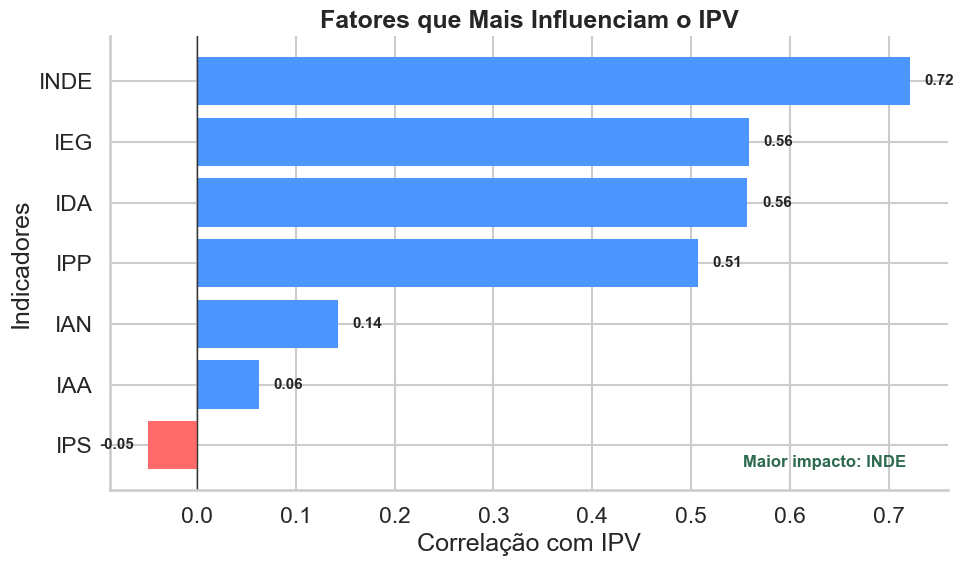

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set(style="whitegrid", context="talk")

# 1. Correlação com IPV
targets = ['ida', 'ieg', 'iaa', 'ips', 'ipp', 'ian', 'inde']

corrs = {}
for t in targets:
    if t in df.columns:
        df_valid = df[['ipv', t]].dropna()
        corrs[t] = df_valid['ipv'].corr(df_valid[t])

corr_df = pd.Series(corrs).sort_values()

# 2. Plot bonito
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#FF6B6B' if v < 0 else '#4D96FF' for v in corr_df.values]

bars = ax.barh(
    corr_df.index.str.upper(),
    corr_df.values,
    color=colors,
    edgecolor='none'
)

# Linha zero
ax.axvline(0, color='#333', lw=1)

# Labels nas barras
for bar, val in zip(bars, corr_df.values):
    ax.text(
        val + (0.015 if val >= 0 else -0.015),
        bar.get_y() + bar.get_height()/2,
        f'{val:.2f}',
        va='center',
        ha='left' if val >= 0 else 'right',
        fontsize=11,
        fontweight='bold'
    )

ax.set_title('Fatores que Mais Influenciam o IPV', fontweight='bold')
ax.set_xlabel('Correlação com IPV')
ax.set_ylabel('Indicadores')

# Destaque TOP 1
top_feature = corr_df.idxmax().upper()
ax.text(
    0.95, 0.05,
    f'Maior impacto: {top_feature}',
    transform=ax.transAxes,
    ha='right',
    fontsize=12,
    fontweight='bold',
    color='#2D6A4F'
)

ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

O gráfico de barras horizontais detalha a correlação entre diversos indicadores e o IPV (Indicador de Ponto de Virada), revelando quais fatores têm maior peso na transformação acadêmica e pessoal do aluno. O INDE aparece como o protagonista absoluto, apresentando a maior correlação positiva (0,72), o que confirma que o desempenho educacional global é o principal motor para que o aluno atinja o ponto de virada. Logo em seguida, o Engajamento (IEG) e o Desempenho Acadêmico (IDA) surgem com impacto idêntico de 0,56, acompanhados de perto pelo IPP (Psicossocial) com 0,51, formando o quarteto de indicadores com forte influência positiva.

Em contrapartida, os indicadores de Adequação de Nível (IAN) e Autoavaliação (IAA) mostram correlações muito baixas, de 0,14 e 0,06 respectivamente, sugerindo que possuem um papel secundário na determinação do IPV. O ponto fora da curva é o IPS (Saúde), que apresenta uma correlação levemente negativa de -0,05, indicando que, neste conjunto de dados específico, oscilações nesse índice não acompanham diretamente a evolução do ponto de virada. Em suma, os dados reforçam que o sucesso no programa está intrinsecamente ligado à combinação de bons resultados acadêmicos, participação ativa e estabilidade psicossocial.

In [17]:
import pandas as pd

# --- EXTRAÇÃO DAS VARIÁVEIS DO DASHBOARD P7 (Corrigido) ---

print(f"{' ANÁLISE DE INFLUÊNCIA NO IPV (P7) ':*^50}")

# 1. Calculando as correlações
targets = ['ida', 'ieg', 'iaa', 'ips', 'ipp', 'ian', 'inde']
corrs = {}

for t in targets:
    if t in df.columns:
        df_valid = df[['ipv', t]].dropna()
        if not df_valid.empty:
            corrs[t] = df_valid['ipv'].corr(df_valid[t])

# 2. Criando a tabela de impacto
tabela_impacto_ipv = pd.Series(corrs).sort_values(ascending=False).to_frame()
tabela_impacto_ipv.columns = ['Correlação']

# 3. Identificando os Extremos (Correção do KeyError)
# Usamos .idxmax() direto na coluna e .max() para o valor
top_1 = tabela_impacto_ipv['Correlação'].idxmax()
valor_top_1 = tabela_impacto_ipv['Correlação'].max()

# --- EXIBIÇÃO DOS RESULTADOS ---

print("\n--- RANKING DE IMPACTO NO IPV ---")
print(tabela_impacto_ipv.round(3))

print("-" * 50)
print(f"VARIÁVEL LÍDER: {top_1.upper()}")
print(f"FORÇA DO IMPACTO: {valor_top_1:.2f}")

# Insight Dinâmico
if valor_top_1 > 0.5:
    status = "FORTE"
elif valor_top_1 > 0.3:
    status = "MODERADA"
else:
    status = "FRACA"

print(f"\nINSIGHT: A influência de {top_1.upper()} sobre o Ponto de Virada é {status}.")
print("="*50)

******* ANÁLISE DE INFLUÊNCIA NO IPV (P7) ********

--- RANKING DE IMPACTO NO IPV ---
      Correlação
inde       0.720
ieg        0.555
ida        0.555
ipp        0.501
ian        0.143
iaa        0.061
ips       -0.049
--------------------------------------------------
VARIÁVEL LÍDER: INDE
FORÇA DO IMPACTO: 0.72

INSIGHT: A influência de INDE sobre o Ponto de Virada é FORTE.


# ❓ P8 – Multidimensionalidade: IA criando Perfis de Alunos (Clusters)
 Objetivo: Usar K-Means para agrupar alunos parecidos sem darmos as regras

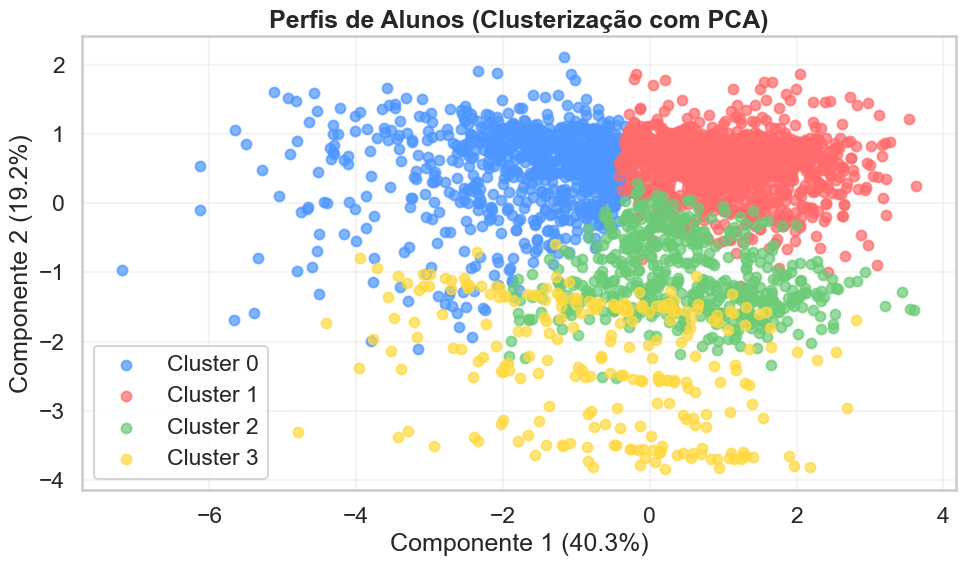

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import numpy as np

# 1. Preparação
cluster_cols = ['ida', 'ieg', 'ips', 'ipp', 'iaa', 'ipv']
df_clust = df[cluster_cols].dropna()
idx_valido = df_clust.index

# 2. Escalonamento
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clust)

# 3. KMeans
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df.loc[idx_valido, 'Cluster'] = clusters

# 4. PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# 5. Plot moderno

plt.figure(figsize=(10, 6))

palette = ['#4D96FF', '#FF6B6B', '#6BCB77', '#FFD93D']

for i in range(4):
    mask = clusters == i
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        s=50,
        alpha=0.7,
        color=palette[i],
        label=f'Cluster {i}'
    )

plt.title('Perfis de Alunos (Clusterização com PCA)', fontweight='bold')
plt.xlabel(f'Componente 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'Componente 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')

plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [23]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Preparação e Limpeza (Garante que só usamos dados válidos)
cluster_cols = ['ida', 'ieg', 'ips', 'ipp', 'iaa', 'ipv']
df_clust = df[cluster_cols].dropna()
idx_valido = df_clust.index

# 2. Escalonamento (Padronização para a IA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clust)

# 3. Execução do KMeans (Criando os 4 grupos)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters_final = kmeans.fit_predict(X_scaled)

# 4. Salvando de volta no DataFrame principal de forma segura
df['Cluster'] = np.nan
df.loc[idx_valido, 'Cluster'] = clusters_final

# 5. EXTRAÇÃO DOS NÚMEROS DO DASHBOARD
df_com_cluster = df.dropna(subset=['Cluster']).copy()
df_com_cluster['Cluster'] = df_com_cluster['Cluster'].astype(int)

# Cálculos de Perfil
cluster_profile = df_com_cluster.groupby('Cluster')[cluster_cols].mean()
cluster_counts = df_com_cluster['Cluster'].value_counts().sort_index()
cluster_pct = (df_com_cluster['Cluster'].value_counts(normalize=True) * 100).sort_index()

# --- RELATÓRIO FINAL ---
print(f"{' PERFIL DOS GRUPOS DE ALUNOS (CLUSTERS) ':*^50}")
print("\n--- DISTRIBUIÇÃO DOS GRUPOS ---")
resumo_qtd = pd.DataFrame({
    'Qtd Alunos': cluster_counts,
    'Percentual (%)': cluster_pct
})
print(resumo_qtd.round(1))

print("\n--- DNA DOS GRUPOS (MÉDIAS DOS INDICADORES) ---")
print(cluster_profile.round(2))

print("\n--- DIAGNÓSTICO ESTRATÉGICO ---")
for i in cluster_profile.index:
    ida_m = cluster_profile.loc[i, 'ida']
    ieg_m = cluster_profile.loc[i, 'ieg']
    
    if ida_m > cluster_profile['ida'].mean():
        desc = "Alta Performance Acadêmica"
    elif ieg_m > cluster_profile['ieg'].mean():
        desc = "Engajamento Elevado (Foco em Conversão de Notas)"
    else:
        desc = "Grupo de Atenção / Risco de Evasão"
        
    print(f"Cluster {i}: {desc}")

print("\n" + "="*50)

***** PERFIL DOS GRUPOS DE ALUNOS (CLUSTERS) *****

--- DISTRIBUIÇÃO DOS GRUPOS ---
         Qtd Alunos  Percentual (%)
Cluster                            
0               503            17.4
1               246             8.5
2              1290            44.7
3               847            29.3

--- DNA DOS GRUPOS (MÉDIAS DOS INDICADORES) ---
          ida   ieg   ips   ipp   iaa   ipv
Cluster                                    
0        6.62  8.83  3.55  7.61  8.58  7.94
1        5.97  7.91  5.48  7.50  0.04  7.58
2        7.53  9.01  7.25  7.93  8.85  8.06
3        4.60  6.80  6.73  7.00  8.46  6.51

--- DIAGNÓSTICO ESTRATÉGICO ---
Cluster 0: Alta Performance Acadêmica
Cluster 1: Grupo de Atenção / Risco de Evasão
Cluster 2: Alta Performance Acadêmica
Cluster 3: Grupo de Atenção / Risco de Evasão





A distribuição revela agrupamentos bem definidos: o Cluster 1 (vermelho) e o Cluster 2 (verde) concentram-se no lado direito do gráfico (valores positivos da Componente 1), sugerindo que compartilham características similares em certas métricas de desempenho ou engajamento. Em contrapartida, o Cluster 0 (azul) estende-se pela lateral esquerda, indicando um perfil com comportamento oposto na primeira componente. Por fim, o Cluster 3 (amarelo) situa-se na base do gráfico (valores negativos da Componente 2), destacando um grupo com particularidades específicas que o diferenciam dos demais, especialmente em relação ao eixo vertical. Essa separação é fundamental para que a Passos Mágicos possa aplicar estratégias de suporte personalizadas para cada perfil identificado.

# 6. ANÁLISE EXPLORATÓRIA FINAL: P10 e P11 (Efetividade e Insights)

# ❓ P10 – Efetividade do Programa (De Quartzo a Topázio)
Objetivo: Mostrar à diretoria que o sistema de "Pedras" funciona. Quem é 
classificado como Topázio realmente tem notas redondas em todas as frentes?

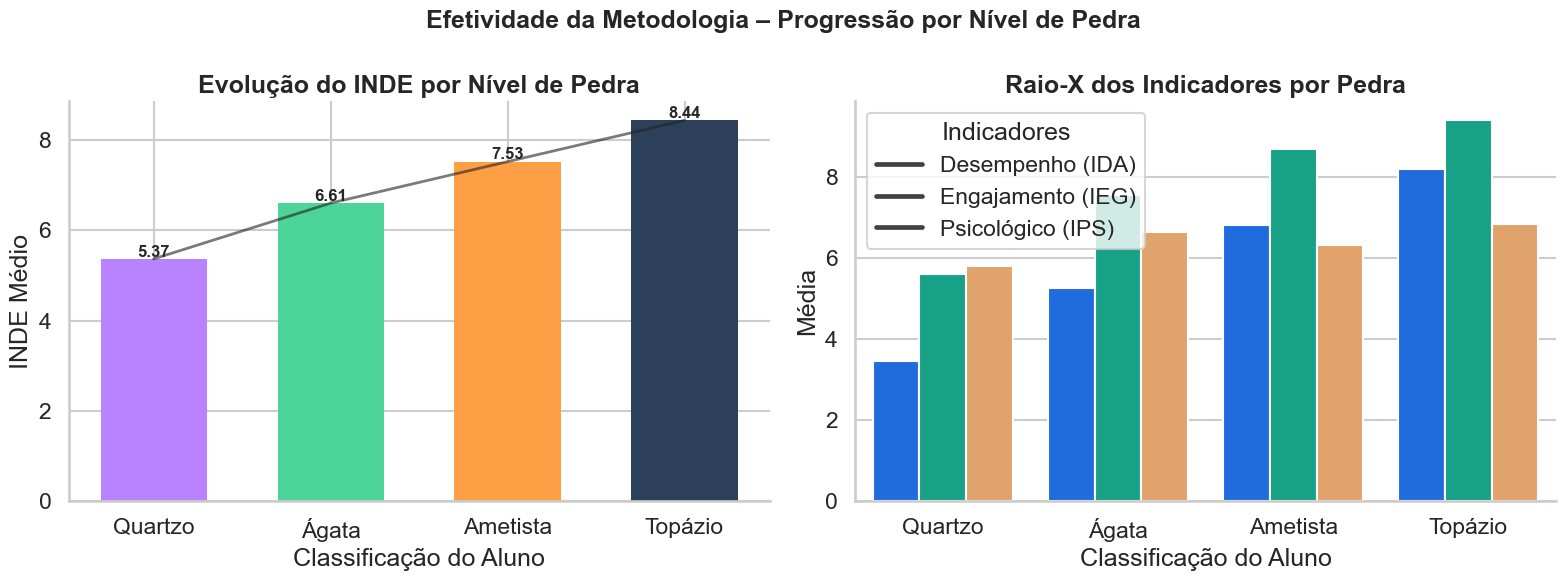

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", context="talk")

pedra_order = ['Quartzo', 'Ágata', 'Ametista', 'Topázio']
df_valido = df[df['pedra'].isin(pedra_order)]

eff = (
    df_valido
    .groupby('pedra')[['inde', 'ida', 'ieg', 'ips']]
    .mean()
    .reindex(pedra_order)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('white')



cores_pedra = ['#B983FF', '#4DD599', '#FF9F45', '#2D4059']

bars = axes[0].bar(
    eff.index,
    eff['inde'],
    color=cores_pedra,
    edgecolor='none',
    width=0.6
)

# Valores nas barras
for b in bars:
    axes[0].text(
        b.get_x() + b.get_width()/2,
        b.get_height() + 0.05,
        f'{b.get_height():.2f}',
        ha='center',
        fontsize=12,
        fontweight='bold'
    )

# Linha de tendência (visual)
axes[0].plot(eff.index, eff['inde'], color='#222', linewidth=2, alpha=0.6)

axes[0].set_title('Evolução do INDE por Nível de Pedra', fontweight='bold')
axes[0].set_xlabel('Classificação do Aluno')
axes[0].set_ylabel('INDE Médio')

axes[0].spines[['top', 'right']].set_visible(False)


eff_melt = eff[['ida', 'ieg', 'ips']].reset_index().melt(
    id_vars='pedra',
    var_name='Indicador',
    value_name='Valor'
)

sns.barplot(
    data=eff_melt,
    x='pedra',
    y='Valor',
    hue='Indicador',
    palette=['#0066FF', '#00B894', '#F4A259'],
    ax=axes[1]
)

axes[1].set_title('Raio-X dos Indicadores por Pedra', fontweight='bold')
axes[1].set_xlabel('Classificação do Aluno')
axes[1].set_ylabel('Média')

axes[1].legend(
    title='Indicadores',
    labels=['Desempenho (IDA)', 'Engajamento (IEG)', 'Psicológico (IPS)']
)

axes[1].spines[['top', 'right']].set_visible(False)


plt.suptitle(
    'Efetividade da Metodologia – Progressão por Nível de Pedra',
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout()
plt.show()



In [24]:
import pandas as pd

# --- EXTRAÇÃO DAS VARIÁVEIS DA JORNADA PEDRA (P9) ---

print(f"{' EFETIVIDADE POR NÍVEL DE PEDRA ':*^50}")

# 1. Definindo a ordem e filtrando os dados
pedra_order = ['Quartzo', 'Ágata', 'Ametista', 'Topázio']

# Recriando a tabela de médias (variável 'eff' do seu gráfico)
tabela_pedras = (
    df[df['pedra'].isin(pedra_order)]
    .groupby('pedra')[['inde', 'ida', 'ieg', 'ips']]
    .mean()
    .reindex(pedra_order)
)

# 2. Calculando a evolução percentual (Diferença Quartzo -> Topázio)
# Isso mostra o "tamanho" da transformação do aluno
evolucao_total_inde = ((tabela_pedras.loc['Topázio', 'inde'] / tabela_pedras.loc['Quartzo', 'inde']) - 1) * 100

# --- EXIBIÇÃO DOS RESULTADOS ---

print("\n--- MÉDIAS POR CATEGORIA (VALORES DO DASHBOARD) ---")
print(tabela_pedras.round(2))

print("\n--- MÉTRICAS DE IMPACTO DA JORNADA ---")
print(f"Crescimento do INDE (Quartzo para Topázio): +{evolucao_total_inde:.1f}%")

# Verificando qual indicador mais cresce
maior_crescimento = (tabela_pedras.loc['Topázio'] / tabela_pedras.loc['Quartzo']).idxmax().upper()
print(f"Indicador com maior salto na jornada: {maior_crescimento}")

print("\n--- INSIGHT PARA O RELATÓRIO ---")
if evolucao_total_inde > 10:
    status = "ALTA EFETIVIDADE: A metodologia mostra uma progressão clara e robusta."
else:
    status = "ESTABILIDADE: A progressão entre os níveis é sutil e constante."
    
print(f"Diagnóstico: {status}")
print("="*50)

********* EFETIVIDADE POR NÍVEL DE PEDRA *********

--- MÉDIAS POR CATEGORIA (VALORES DO DASHBOARD) ---
          inde   ida   ieg   ips
pedra                           
Quartzo   5.37  3.47  5.62  5.77
Ágata     6.61  5.25  7.54  6.63
Ametista  7.53  6.81  8.69  6.30
Topázio   8.44  8.18  9.39  6.84

--- MÉTRICAS DE IMPACTO DA JORNADA ---
Crescimento do INDE (Quartzo para Topázio): +57.1%
Indicador com maior salto na jornada: IDA

--- INSIGHT PARA O RELATÓRIO ---
Diagnóstico: ALTA EFETIVIDADE: A metodologia mostra uma progressão clara e robusta.


Os gráficos apresentados reforçam a Efetividade da Metodologia da Passos Mágicos, demonstrando como o amadurecimento acadêmico dos alunos reflete diretamente em seus índices. No primeiro gráfico, Evolução do INDE por Nível de Pedra, observa-se uma trajetória de crescimento constante e linear: o índice parte de 5,37 no nível Quartzo e atinge o ápice de 8,44 no nível Topázio, evidenciando que a progressão na classificação da associação está atrelada a uma melhora real no desempenho geral.

Complementando essa visão, o Raio-X dos Indicadores por Pedra detalha quais pilares sustentam essa evolução. É notável que o Engajamento (IEG) e o Desempenho (IDA) apresentam os saltos mais expressivos conforme o aluno avança de nível, sugerindo que a permanência no projeto fortalece o compromisso e o resultado acadêmico. Já o indicador Psicológico (IPS) mantém-se mais estável e elevado desde o início, servindo como uma base emocional sólida que permite ao aluno focar em seu crescimento técnico e participativo até


# ❓ P11 – Insights Adicionais: Bolsas e Gênero
 Objetivo: Responder a duas perguntas de ouro:
1. Meninos e meninas têm o mesmo desempenho?
2. Quem é indicado para bolsa realmente tem notas matematicamente superiores?


1️⃣ Desempenho (INDE Médio) por Gênero:


genero
Feminino     7.34
Masculino    7.19
Name: inde, dtype: float64

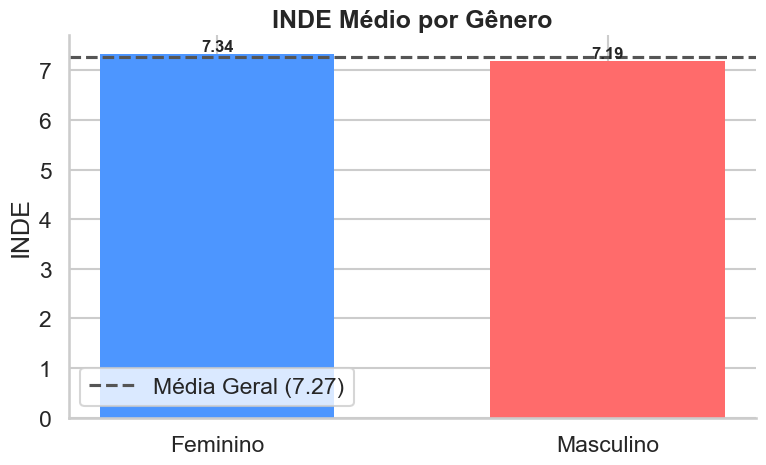

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", context="talk")

gen_inde = df.groupby('genero')['inde'].mean().sort_values(ascending=False)

print('\n1️⃣ Desempenho (INDE Médio) por Gênero:')
display(gen_inde.round(2))

fig, ax = plt.subplots(figsize=(8, 5))

cores = ['#4D96FF', '#FF6B6B']

bars = ax.bar(
    gen_inde.index,
    gen_inde.values,
    color=cores,
    edgecolor='none',
    width=0.6
)

# Valores nas barras
for b in bars:
    ax.text(
        b.get_x() + b.get_width()/2,
        b.get_height() + 0.05,
        f'{b.get_height():.2f}',
        ha='center',
        fontsize=12,
        fontweight='bold'
    )

# Linha média geral
media = df['inde'].mean()
ax.axhline(media, linestyle='--', color='#555', label=f'Média Geral ({media:.2f})')

ax.set_title('INDE Médio por Gênero', fontweight='bold')
ax.set_ylabel('INDE')
ax.set_xlabel('')

ax.spines[['top', 'right']].set_visible(False)
ax.legend()

plt.tight_layout()
plt.show()

O gráfico apresenta o Índice de Desenvolvimento Educacional (INDE) Médio segmentado por gênero, revelando um desempenho ligeiramente superior das alunas em comparação aos alunos. Enquanto o grupo feminino alcançou uma média de 7,34, o grupo masculino registrou 7,19. Ao utilizarmos a Média Geral de 7,27 como ponto de referência (indicada pela linha tracejada), observa-se que as mulheres estão acima desse patamar, enquanto os homens situam-se um pouco abaixo. Apesar dessa variação, a diferença de apenas 0,15 pontos entre os gêneros sugere um cenário de equilíbrio, com ambos os grupos mantendo um nível de aproveitamento bastante próximo e consistente dentro da instituição.


2️ Impacto da Indicação de Bolsa:


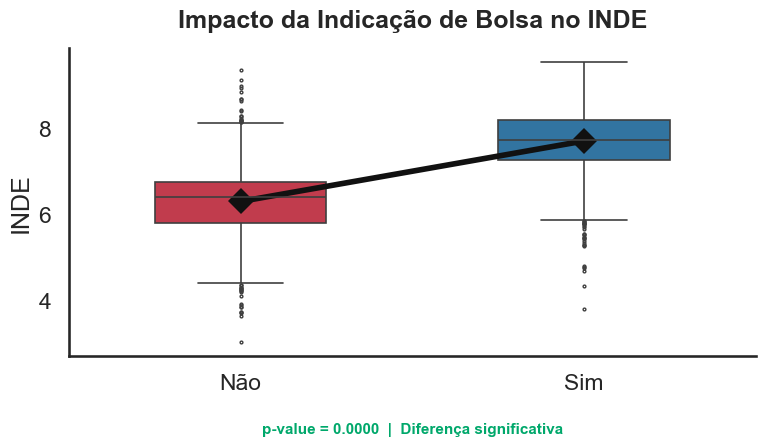

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set(style="white", context="talk")

print('\n2️ Impacto da Indicação de Bolsa:')

df_bolsa = df[df['indicado_bolsa'].isin(['Sim', 'Não'])]


# Estatística

grupo_sim = df_bolsa[df_bolsa['indicado_bolsa'] == 'Sim']['inde']
grupo_nao = df_bolsa[df_bolsa['indicado_bolsa'] == 'Não']['inde']

t_stat, p_val = stats.ttest_ind(grupo_sim, grupo_nao, equal_var=False)

if p_val < 0.05:
    conclusao = "Diferença significativa"
    cor = "#00A86B"
else:
    conclusao = "Sem diferença significativa"
    cor = "#D7263D"


# Gráfico bonito

plt.figure(figsize=(8, 5))

# Boxplot elegante
sns.boxplot(
    data=df_bolsa,
    x='indicado_bolsa',
    y='inde',
    width=0.5,
    palette=['#D7263D', '#1F77B4'],
    fliersize=2,
    linewidth=1.2
)

# Média como ponto
sns.pointplot(
    data=df_bolsa,
    x='indicado_bolsa',
    y='inde',
    color='#111',
    markers='D',
    errorbar=None
)

# Título e labels
plt.title('Impacto da Indicação de Bolsa no INDE', fontweight='bold', pad=15)
plt.xlabel('')
plt.ylabel('INDE')

# Remover bordas feias
ax = plt.gca()
ax.spines[['top', 'right']].set_visible(False)

# Texto mais elegante (tipo badge)
plt.text(
    0.5, -0.25,
    f'p-value = {p_val:.4f}  |  {conclusao}',
    transform=ax.transAxes,
    ha='center',
    fontsize=11,
    color=cor,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

O gráfico evidencia uma diferença consistente entre os grupos de alunos indicados e não indicados para bolsa. Observa-se que os alunos indicados (“Sim”) apresentam valores de INDE significativamente mais elevados, com a média posicionada em um nível superior ao grupo “Não”. Além disso, a distribuição dos dados mostra que os quartis do grupo indicado estão deslocados para cima, indicando não apenas maior desempenho médio, mas também uma concentração maior de alunos em faixas de desempenho mais altas.

A presença de um p-value extremamente baixo (≈ 0.0000) confirma que essa diferença não ocorre por acaso, sendo estatisticamente significativa. Isso sugere que o processo de indicação à bolsa está, de fato, selecionando alunos com melhor desempenho acadêmico global.

Outro ponto relevante é a menor dispersão relativa dos alunos indicados, indicando maior consistência nos resultados, enquanto o grupo não indicado apresenta maior variabilidade e concentração em faixas inferiores de desempenho.

No entanto, é importante destacar que essa análise indica associação e não causalidade. Ou seja, não é possível afirmar que a bolsa melhora o desempenho, mas sim que alunos com melhor desempenho têm maior probabilidade de serem indicados.

Em síntese, os dados indicam que o critério de indicação à bolsa é eficaz na identificação de alunos com maior desempenho e consistência acadêmica.